# CSE428 — Pet Segmentation & Classification

**Dataset:** Oxford-IIIT Pet (37 breeds) — local layout: `images/` and `trimaps/` next to this notebook.

**Pipeline:**
1. Dataset exploration (3×3 grid with mask overlays)
2. Base U-Net + classifier head — joint training
3. Attention U-Net + classifier head — joint training
4. Per-image visualisation: original | true overlay | predicted overlay

All checkpoints are saved to `./checkpoints/` so training can resume across sessions.


## 0 — Install / verify dependencies

In [14]:
# Run once. Skip if your env already has these.
import sys
!{sys.executable} -m pip install -q opencv-python-headless scikit-learn tqdm matplotlib pillow torch torchvision


## 1 — Configuration & checkpoint utilities

In [15]:
import os
import torch

# ── Project paths ──────────────────────────────────────────────────────────
# Your layout: images/ and trimaps/ live in the same folder as this notebook.
BASE_DIR       = os.path.abspath(".")
IMAGE_DIR      = os.path.join(BASE_DIR, "images")
MASK_DIR       = os.path.join(BASE_DIR, "trimaps")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

assert os.path.isdir(IMAGE_DIR), f"IMAGE_DIR not found: {IMAGE_DIR}"
assert os.path.isdir(MASK_DIR),  f"MASK_DIR not found: {MASK_DIR}"

print(f"IMAGE_DIR      : {IMAGE_DIR}")
print(f"MASK_DIR       : {MASK_DIR}")
print(f"CHECKPOINT_DIR : {CHECKPOINT_DIR}")

# ── Device ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Reproducibility ────────────────────────────────────────────────────────
import random, numpy as np
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)


IMAGE_DIR      : E:\cse428_f\images
MASK_DIR       : E:\cse428_f\trimaps
CHECKPOINT_DIR : E:\cse428_f\checkpoints

Using device: cuda
  GPU : NVIDIA GeForce RTX 3070
  VRAM: 8.6 GB


In [16]:
# ── Checkpoint helpers ─────────────────────────────────────────────────────
def save_checkpoint(state: dict, filename: str = "checkpoint.pth.tar") -> None:
    path = os.path.join(CHECKPOINT_DIR, filename)
    torch.save(state, path)
    print(f"  [✓] Checkpoint saved → {path}")


def load_checkpoint(filename: str, model: torch.nn.Module,
                    optimizer: torch.optim.Optimizer):
    """Load a checkpoint. Returns (start_epoch, best_loss, history)."""
    path = os.path.join(CHECKPOINT_DIR, filename)
    if not os.path.exists(path):
        print(f"  [i] No checkpoint at {path}. Starting from scratch.")
        return 0, float("inf"), None

    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    optimizer.load_state_dict(ckpt["optimizer"])
    epoch     = ckpt.get("epoch", 0)
    best_loss = ckpt.get("best_loss", float("inf"))
    history   = ckpt.get("history", None)
    print(f"  [✓] Loaded {path}  |  resume after epoch {epoch}  |  best_val={best_loss:.4f}")
    return epoch + 1, best_loss, history


## 2 — Dataset discovery

The Oxford-IIIT Pet naming convention:
- Filenames starting with an **uppercase** letter → **cat** breeds (e.g. `Abyssinian_1.jpg`).
- Filenames starting with a **lowercase** letter → **dog** breeds (e.g. `beagle_1.jpg`).

We use this to build the species (cat/dog) tag for plotting.


In [17]:
import glob

image_paths = sorted([
    f for f in glob.glob(os.path.join(IMAGE_DIR, "*.jpg"))
    if not os.path.basename(f).startswith(".")
])

mask_paths, valid_images = [], []
for img_path in image_paths:
    mask_file = os.path.basename(img_path).replace(".jpg", ".png")
    m_path = os.path.join(MASK_DIR, mask_file)
    if os.path.exists(m_path):
        valid_images.append(img_path)
        mask_paths.append(m_path)

print(f"Total .jpg files in images/   : {len(image_paths)}")
print(f"Matched image-mask pairs      : {len(valid_images)}")


Total .jpg files in images/   : 7390
Matched image-mask pairs      : 7390


## 3 — Dataset exploration: 3×3 grid with mask overlays

The trimap pixels are:
- `1` → foreground (pet)
- `2` → background
- `3` → boundary / unclassified

Per the spec, we merge **boundary (3) → foreground (1)** to get a binary mask.


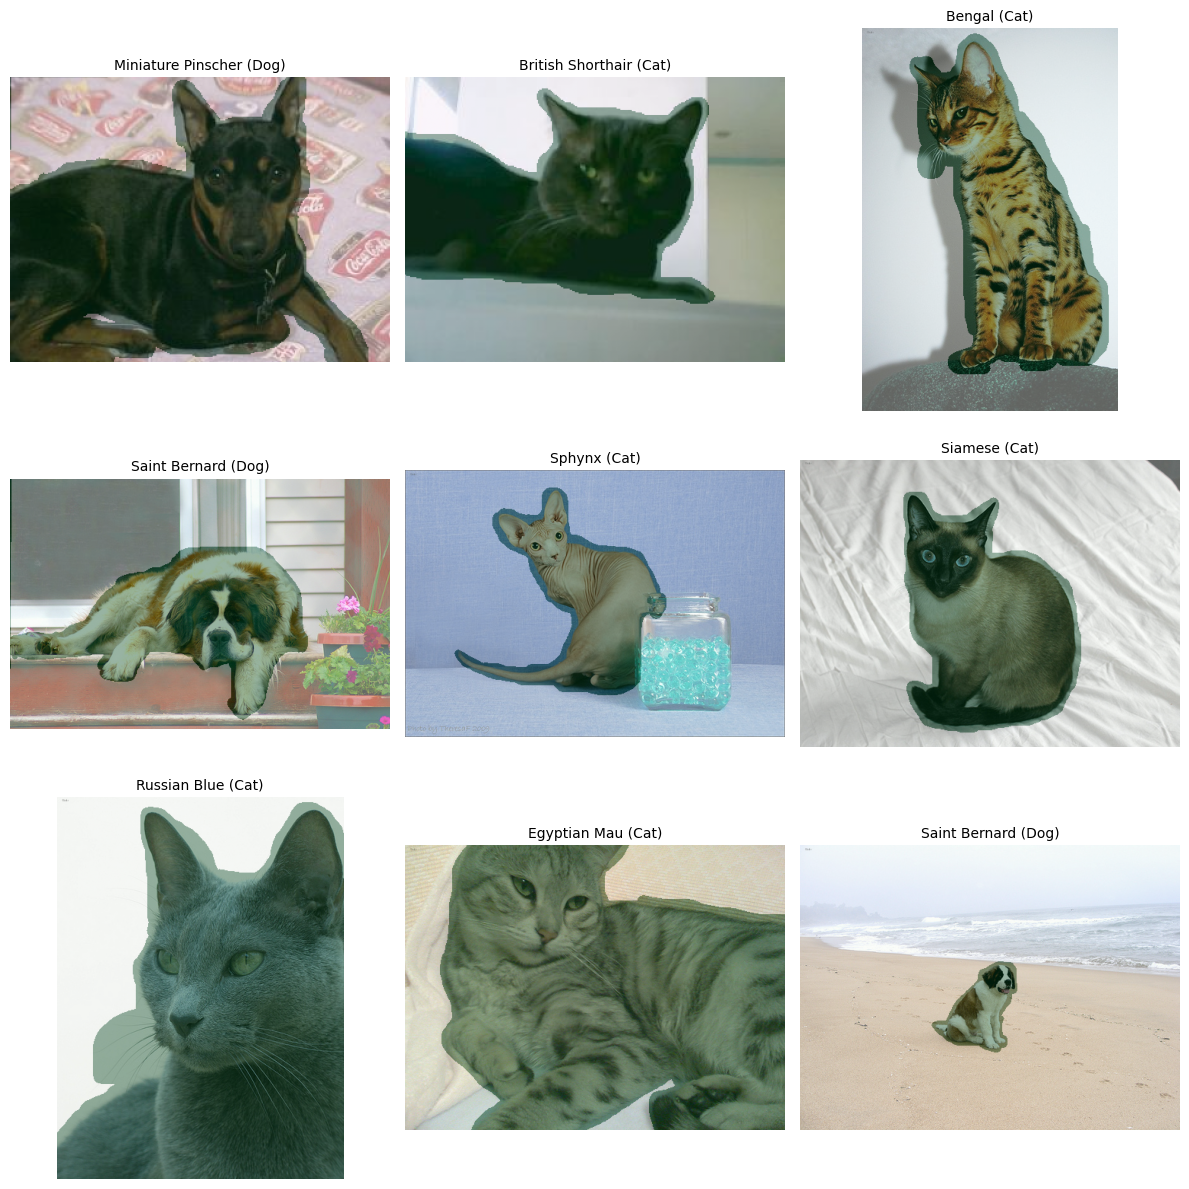

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random


def species_from_filename(path: str) -> str:
    """Cat if filename basename starts uppercase, else Dog (Oxford-IIIT convention)."""
    return "Cat" if os.path.basename(path)[0].isupper() else "Dog"


def breed_from_filename(path: str) -> str:
    base = os.path.basename(path)
    breed = base.rsplit("_", 1)[0]
    return " ".join(p.capitalize() for p in breed.split("_"))


def get_label_info(path: str) -> str:
    return f"{breed_from_filename(path)} ({species_from_filename(path)})"


def trimap_to_binary(mask_np: np.ndarray) -> np.ndarray:
    """Boundary (3) and foreground (1) → 1; background (2) → 0."""
    return np.where(mask_np == 2, 0, 1).astype(np.uint8)


def plot_guideline_grid(imgs, masks, n: int = 9, seed: int = None):
    """Plot n random images with foreground mask overlays in a 3×3 grid."""
    if seed is not None:
        random.seed(seed)
    indices = random.sample(range(len(imgs)), n)
    nrows = int(n ** 0.5)
    ncols = (n + nrows - 1) // nrows

    plt.figure(figsize=(4 * ncols, 4 * nrows))
    for i, idx in enumerate(indices):
        img  = cv2.cvtColor(cv2.imread(imgs[idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(masks[idx], cv2.IMREAD_GRAYSCALE)
        binary = trimap_to_binary(mask)

        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(img)
        plt.imshow(binary, alpha=0.4, cmap="Greens")
        plt.title(get_label_info(imgs[idx]), fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


plot_guideline_grid(valid_images, mask_paths, n=9, seed=42)


## 4 — Breed → index map

In [19]:
def get_breed_maps(image_paths):
    breeds = sorted({os.path.basename(p).rsplit("_", 1)[0] for p in image_paths})
    breed_to_idx = {b: i for i, b in enumerate(breeds)}
    idx_to_breed = {i: b for b, i in breed_to_idx.items()}
    return breed_to_idx, idx_to_breed


breed_to_idx, idx_to_breed = get_breed_maps(valid_images)
num_classes = len(breed_to_idx)
print(f"Total unique breeds: {num_classes}")
print("First 5 breeds:", list(breed_to_idx.keys())[:5])


Total unique breeds: 37
First 5 breeds: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair']


## 5 — Stratified train / val / test split (80 / 10 / 10)

In [20]:
from sklearn.model_selection import train_test_split

stratify_labels = [os.path.basename(f).rsplit("_", 1)[0] for f in valid_images]

train_val_imgs, test_imgs, train_val_masks, test_masks = train_test_split(
    valid_images, mask_paths,
    test_size=0.10, random_state=SEED, stratify=stratify_labels
)

stratify_tv = [os.path.basename(f).rsplit("_", 1)[0] for f in train_val_imgs]
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_val_imgs, train_val_masks,
    test_size=0.1111, random_state=SEED, stratify=stratify_tv
)

print(f"Train : {len(train_imgs):>5d}")
print(f"Val   : {len(val_imgs):>5d}")
print(f"Test  : {len(test_imgs):>5d}")


Train :  5912
Val   :   739
Test  :   739


## 6 — Dataset class & DataLoaders

**Important:** We apply spatial augmentations (flip, rotation) to the **image and mask jointly**
so the mask still aligns with the augmented image. Color jitter is image-only.


In [21]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image
import platform

IMG_SIZE   = 128
BATCH_SIZE = 16   # lower (e.g. 8) if you run out of VRAM

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


class PetDataset(Dataset):
    """
    Returns (image_tensor, mask_tensor[long, H×W with 0/1], breed_label[long]).
    Augmentation is applied jointly to image and mask when train=True.
    """
    def __init__(self, image_paths, mask_paths, breed_to_idx, train: bool = False):
        self.image_paths  = image_paths
        self.mask_paths   = mask_paths
        self.breed_to_idx = breed_to_idx
        self.train        = train
        self.color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
        self.normalize    = transforms.Normalize(mean=MEAN, std=STD)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask  = Image.open(self.mask_paths[idx])

        # Resize (image bilinear, mask nearest)
        image = TF.resize(image, [IMG_SIZE, IMG_SIZE])
        mask  = TF.resize(mask,  [IMG_SIZE, IMG_SIZE],
                          interpolation=transforms.InterpolationMode.NEAREST)

        if self.train:
            # Joint horizontal flip
            if random.random() < 0.5:
                image = TF.hflip(image); mask = TF.hflip(mask)
            # Joint rotation
            if random.random() < 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle, interpolation=transforms.InterpolationMode.BILINEAR)
                mask  = TF.rotate(mask,  angle, interpolation=transforms.InterpolationMode.NEAREST)
            # Image-only color jitter
            image = self.color_jitter(image)

        # Image → tensor + normalize
        image = TF.to_tensor(image)
        image = self.normalize(image)

        # Mask → binary 0/1 long tensor (boundary 3 → fg 1)
        mask_np = np.array(mask)
        mask_np = np.where(mask_np == 2, 0, 1).astype(np.int64)
        mask_t  = torch.from_numpy(mask_np)

        breed = os.path.basename(self.image_paths[idx]).rsplit("_", 1)[0]
        label = self.breed_to_idx[breed]

        return image, mask_t, torch.tensor(label, dtype=torch.long)


NUM_WORKERS = 0 if platform.system() == "Windows" else 4

train_dataset = PetDataset(train_imgs, train_masks, breed_to_idx, train=True)
val_dataset   = PetDataset(val_imgs,   val_masks,   breed_to_idx, train=False)
test_dataset  = PetDataset(test_imgs,  test_masks,  breed_to_idx, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))

# Sanity check one batch
img_b, msk_b, lbl_b = next(iter(train_loader))
print(f"Image batch : {img_b.shape}  dtype={img_b.dtype}")
print(f"Mask  batch : {msk_b.shape}  dtype={msk_b.dtype}  unique={torch.unique(msk_b).tolist()}")
print(f"Label batch : {lbl_b.shape}  dtype={lbl_b.dtype}  range=[{lbl_b.min().item()}, {lbl_b.max().item()}]")


Image batch : torch.Size([16, 3, 128, 128])  dtype=torch.float32
Mask  batch : torch.Size([16, 128, 128])  dtype=torch.int64  unique=[0, 1]
Label batch : torch.Size([16])  dtype=torch.int64  range=[0, 35]


## 7 — Base U-Net + classifier head

Standard U-Net (Ronneberger et al., 2015) with the classifier head attached to the
**bottleneck (encoder output)** as required.


In [22]:
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    """Two 3×3 conv + BN + ReLU, with optional dropout."""
    def __init__(self, in_c, out_c, dropout_rate=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c,  out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNetClassifier(nn.Module):
    """U-Net with a classifier head attached to the bottleneck (encoder output)."""

    def __init__(self, num_breeds: int = 37):
        super().__init__()
        # Encoder
        self.e1 = ConvBlock(3,    64)
        self.e2 = ConvBlock(64,  128)
        self.e3 = ConvBlock(128, 256)
        self.e4 = ConvBlock(256, 512)

        # Bottleneck
        self.b  = ConvBlock(512, 1024, dropout_rate=0.3)

        # Classifier head — attached to bottleneck output
        self.avgpool    = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_breeds),
        )

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.d4  = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512,  256, 2, stride=2)
        self.d3  = ConvBlock(512,  256)
        self.up2 = nn.ConvTranspose2d(256,  128, 2, stride=2)
        self.d2  = ConvBlock(256,  128)
        self.up1 = nn.ConvTranspose2d(128,   64, 2, stride=2)
        self.d1  = ConvBlock(128,   64)

        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.e1(x);  p1 = F.max_pool2d(s1, 2)
        s2 = self.e2(p1); p2 = F.max_pool2d(s2, 2)
        s3 = self.e3(p2); p3 = F.max_pool2d(s3, 2)
        s4 = self.e4(p3); p4 = F.max_pool2d(s4, 2)

        bridge    = self.b(p4)
        class_out = self.classifier(self.avgpool(bridge))

        u4 = self.up4(bridge); d4 = self.d4(torch.cat([u4, s4], dim=1))
        u3 = self.up3(d4);     d3 = self.d3(torch.cat([u3, s3], dim=1))
        u2 = self.up2(d3);     d2 = self.d2(torch.cat([u2, s2], dim=1))
        u1 = self.up1(d2);     d1 = self.d1(torch.cat([u1, s1], dim=1))

        mask_out = self.out_conv(d1)
        return mask_out, class_out


# Sanity check
_m = UNetClassifier(num_breeds=num_classes)
_seg, _cls = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
print(f"U-Net  seg: {_seg.shape}   cls: {_cls.shape}")
total_params = sum(p.numel() for p in _m.parameters())
print(f"Total params: {total_params/1e6:.2f} M")
del _m


U-Net  seg: torch.Size([2, 1, 128, 128])   cls: torch.Size([2, 37])
Total params: 31.59 M


## 8 — Attention U-Net

Identical encoder/decoder, but each skip connection is gated by a soft attention block
(Oktay et al., 2018) so the decoder learns *where* to attend in the skip features.


In [23]:
class AttentionGate(nn.Module):
    """Soft attention gate (Oktay et al., 2018, arXiv:1804.03999)."""

    def __init__(self, g_channels: int, x_channels: int, inter_channels: int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, inter_channels, 1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, inter_channels, 1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # g: gating signal (decoder), x: skip connection (encoder)
        g1  = self.W_g(g)
        x1  = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AttentionUNetClassifier(nn.Module):
    """Attention U-Net with the same classifier head as Base U-Net."""

    def __init__(self, num_breeds: int = 37):
        super().__init__()
        # Encoder (identical to U-Net)
        self.e1 = ConvBlock(3,    64)
        self.e2 = ConvBlock(64,  128)
        self.e3 = ConvBlock(128, 256)
        self.e4 = ConvBlock(256, 512)
        self.b  = ConvBlock(512, 1024, dropout_rate=0.3)

        # Classifier head
        self.avgpool    = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_breeds),
        )

        # Attention gates (one per skip)
        self.att4 = AttentionGate(g_channels=512, x_channels=512, inter_channels=256)
        self.att3 = AttentionGate(g_channels=256, x_channels=256, inter_channels=128)
        self.att2 = AttentionGate(g_channels=128, x_channels=128, inter_channels=64)
        self.att1 = AttentionGate(g_channels=64,  x_channels=64,  inter_channels=32)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.d4  = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512,  256, 2, stride=2)
        self.d3  = ConvBlock(512,  256)
        self.up2 = nn.ConvTranspose2d(256,  128, 2, stride=2)
        self.d2  = ConvBlock(256,  128)
        self.up1 = nn.ConvTranspose2d(128,   64, 2, stride=2)
        self.d1  = ConvBlock(128,   64)

        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.e1(x);  p1 = F.max_pool2d(s1, 2)
        s2 = self.e2(p1); p2 = F.max_pool2d(s2, 2)
        s3 = self.e3(p2); p3 = F.max_pool2d(s3, 2)
        s4 = self.e4(p3); p4 = F.max_pool2d(s4, 2)

        bridge    = self.b(p4)
        class_out = self.classifier(self.avgpool(bridge))

        u4 = self.up4(bridge); s4a = self.att4(u4, s4); d4 = self.d4(torch.cat([u4, s4a], 1))
        u3 = self.up3(d4);     s3a = self.att3(u3, s3); d3 = self.d3(torch.cat([u3, s3a], 1))
        u2 = self.up2(d3);     s2a = self.att2(u2, s2); d2 = self.d2(torch.cat([u2, s2a], 1))
        u1 = self.up1(d2);     s1a = self.att1(u1, s1); d1 = self.d1(torch.cat([u1, s1a], 1))

        return self.out_conv(d1), class_out


# Sanity check
_m = AttentionUNetClassifier(num_breeds=num_classes)
_seg, _cls = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
print(f"Attention U-Net  seg: {_seg.shape}   cls: {_cls.shape}")
total_params = sum(p.numel() for p in _m.parameters())
print(f"Total params: {total_params/1e6:.2f} M")
del _m


Attention U-Net  seg: torch.Size([2, 1, 128, 128])   cls: torch.Size([2, 37])
Total params: 31.94 M


## 9 — Metrics & early stopping

In [24]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


def compute_seg_metrics(pred_logits, target_mask):
    """
    Per-batch IoU, Dice, pixel accuracy. target_mask shape: (B, 1, H, W) float.
    """
    pred = (torch.sigmoid(pred_logits) > 0.5).float()
    tgt  = target_mask.float()
    intersection = (pred * tgt).sum()
    union        = pred.sum() + tgt.sum() - intersection
    iou   = (intersection / (union + 1e-7)).item()
    dice  = (2.0 * intersection / (pred.sum() + tgt.sum() + 1e-7)).item()
    pix   = (pred == tgt).float().mean().item()
    return iou, dice, pix


class EarlyStopping:
    """Stops training when val loss stops improving and saves the best checkpoint."""

    def __init__(self, patience: int = 10, checkpoint_name: str = "checkpoint.pth.tar"):
        self.patience        = patience
        self.counter         = 0
        self.best_loss       = float("inf")
        self.early_stop      = False
        self.checkpoint_name = checkpoint_name

    def __call__(self, val_loss: float, model, optimizer, epoch: int, history: dict):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            save_checkpoint({
                "epoch":      epoch,
                "state_dict": model.state_dict(),
                "optimizer":  optimizer.state_dict(),
                "best_loss":  self.best_loss,
                "history":    history,
            }, filename=self.checkpoint_name)
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


print("Metric helpers and EarlyStopping defined.")


Metric helpers and EarlyStopping defined.


## 10 — Joint training loop (segmentation + classification)

In [25]:
from tqdm import tqdm
import torch.optim as optim


def train_dual_task(model, train_loader, val_loader, optimizer,
                    epochs: int = 50, checkpoint_name: str = "checkpoint.pth.tar",
                    start_epoch: int = 0, best_loss: float = float("inf"),
                    history: dict = None, scheduler=None):
    """
    Train segmentation + classification jointly. Tracks loss, accuracy, mIoU and
    Dice per epoch on both train and val splits so we can show full curves.
    """
    if history is None:
        history = {
            "train_loss": [], "val_loss": [],
            "train_acc":  [], "val_acc":  [],
            "train_iou":  [], "val_iou":  [],
            "train_dice": [], "val_dice": [],
        }

    early_stop = EarlyStopping(patience=10, checkpoint_name=checkpoint_name)
    early_stop.best_loss = best_loss

    seg_crit = nn.BCEWithLogitsLoss()
    cls_crit = nn.CrossEntropyLoss()

    for epoch in range(start_epoch, epochs):
        # ── Training ────────────────────────────────────────────────────────
        model.train()
        t_loss = 0.0; t_correct = t_total = 0
        t_iou_sum = t_dice_sum = 0.0; t_batches = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]", leave=False)
        for imgs, masks, labels in loop:
            imgs   = imgs.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            m_p, c_p = model(imgs)
            target   = masks.unsqueeze(1).float()

            loss_seg = seg_crit(m_p, target)
            loss_cls = cls_crit(c_p, labels)
            loss     = loss_seg + loss_cls
            loss.backward()
            optimizer.step()

            t_loss   += loss.item()
            t_correct += (c_p.argmax(1) == labels).sum().item()
            t_total   += labels.size(0)

            with torch.no_grad():
                iou, dice, _ = compute_seg_metrics(m_p, target)
            t_iou_sum  += iou
            t_dice_sum += dice
            t_batches  += 1
            loop.set_postfix(loss=f"{loss.item():.4f}", iou=f"{iou:.3f}")

        # ── Validation ──────────────────────────────────────────────────────
        model.eval()
        v_loss = 0.0; v_correct = v_total = 0
        v_iou_sum = v_dice_sum = 0.0; v_batches = 0
        with torch.no_grad():
            for imgs, masks, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]", leave=False):
                imgs   = imgs.to(device, non_blocking=True)
                masks  = masks.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                m_p, c_p = model(imgs)
                target   = masks.unsqueeze(1).float()
                v_loss   += (seg_crit(m_p, target) + cls_crit(c_p, labels)).item()
                v_correct += (c_p.argmax(1) == labels).sum().item()
                v_total   += labels.size(0)

                iou, dice, _ = compute_seg_metrics(m_p, target)
                v_iou_sum  += iou
                v_dice_sum += dice
                v_batches  += 1

        train_loss = t_loss / max(1, len(train_loader))
        val_loss   = v_loss / max(1, len(val_loader))
        train_acc  = t_correct / max(1, t_total)
        val_acc    = v_correct / max(1, v_total)
        train_iou  = t_iou_sum  / max(1, t_batches)
        val_iou    = v_iou_sum  / max(1, v_batches)
        train_dice = t_dice_sum / max(1, t_batches)
        val_dice   = v_dice_sum / max(1, v_batches)

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
        history["train_iou"].append(train_iou);   history["val_iou"].append(val_iou)
        history["train_dice"].append(train_dice); history["val_dice"].append(val_dice)

        print(f"Ep {epoch+1:3d}/{epochs} | "
              f"loss {train_loss:.4f}/{val_loss:.4f} | "
              f"acc {train_acc:.3f}/{val_acc:.3f} | "
              f"IoU {train_iou:.3f}/{val_iou:.3f} | "
              f"Dice {train_dice:.3f}/{val_dice:.3f}")

        if scheduler is not None:
            scheduler.step(val_loss)

        early_stop(val_loss, model, optimizer, epoch, history)
        if early_stop.early_stop:
            print("Early stopping triggered. Best checkpoint already saved.")
            break

    return history


print("train_dual_task() defined.")


train_dual_task() defined.


## 11 — Evaluation & curve plotting helper

In [26]:
def plot_history(history: dict, title: str = "Model"):
    """Plot loss, accuracy, mIoU and Dice curves."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(epochs, history["train_loss"], label="Train")
    axes[0, 0].plot(epochs, history["val_loss"],   label="Val")
    axes[0, 0].set_title(f"{title} — Total Loss"); axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(epochs, history["train_acc"], label="Train")
    axes[0, 1].plot(epochs, history["val_acc"],   label="Val")
    axes[0, 1].set_title(f"{title} — Classification Accuracy"); axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    if "train_iou" in history and len(history["train_iou"]) > 0:
        axes[1, 0].plot(epochs, history["train_iou"], label="Train")
        axes[1, 0].plot(epochs, history["val_iou"],   label="Val")
        axes[1, 0].set_title(f"{title} — mIoU"); axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

        axes[1, 1].plot(epochs, history["train_dice"], label="Train")
        axes[1, 1].plot(epochs, history["val_dice"],   label="Val")
        axes[1, 1].set_title(f"{title} — Dice"); axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()


def evaluate_split(model, loader, split_name: str):
    """
    Compute all the required metrics on a split:
    - Segmentation: mIoU, Dice, pixel accuracy
    - Classification: accuracy, precision, recall, F1 (weighted)
    """
    model.eval()
    all_pred, all_true = [], []
    iou_sum = dice_sum = pix_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for imgs, masks, labels in loader:
            imgs   = imgs.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            m_p, c_p = model(imgs)
            target   = masks.unsqueeze(1).float()

            iou, dice, pix = compute_seg_metrics(m_p, target)
            iou_sum  += iou
            dice_sum += dice
            pix_sum  += pix
            n_batches += 1

            all_pred.extend(c_p.argmax(1).cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    prec, rec, f1, _ = precision_recall_fscore_support(
        all_true, all_pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(all_true, all_pred)
    n_batches = max(1, n_batches)

    print(f"{'='*55}")
    print(f"  {split_name}")
    print(f"{'='*55}")
    print(f"  Segmentation   mIoU       : {iou_sum  / n_batches:.4f}")
    print(f"                 Dice       : {dice_sum / n_batches:.4f}")
    print(f"                 Pixel Acc  : {pix_sum  / n_batches:.4f}")
    print(f"  Classification Accuracy   : {acc:.4f}")
    print(f"                 Precision  : {prec:.4f}")
    print(f"                 Recall     : {rec:.4f}")
    print(f"                 F1 (wt)    : {f1:.4f}")
    print(f"{'='*55}\n")

    return {
        "miou": iou_sum / n_batches,
        "dice": dice_sum / n_batches,
        "pix":  pix_sum  / n_batches,
        "acc":  acc, "prec": prec, "rec": rec, "f1": f1,
    }


## 12 — Train Base U-Net

*Re-running this cell automatically resumes from the last saved checkpoint.*

In [27]:
BASE_CKPT = "base_unet_checkpoint.pth.tar"
EPOCHS    = 50

base_model = UNetClassifier(num_breeds=num_classes).to(device)
base_optim = optim.Adam(base_model.parameters(), lr=1e-4, weight_decay=1e-5)
base_sched = optim.lr_scheduler.ReduceLROnPlateau(base_optim, mode="min", patience=5, factor=0.5)

start_epoch, best_loss, base_history = load_checkpoint(BASE_CKPT, base_model, base_optim)

base_history = train_dual_task(
    model           = base_model,
    train_loader    = train_loader,
    val_loader      = val_loader,
    optimizer       = base_optim,
    epochs          = EPOCHS,
    checkpoint_name = BASE_CKPT,
    start_epoch     = start_epoch,
    best_loss       = best_loss,
    history         = base_history,
    scheduler       = base_sched,
)


  [i] No checkpoint at E:\cse428_f\checkpoints\base_unet_checkpoint.pth.tar. Starting from scratch.


Ep   1/50 | loss 4.0135/3.7796 | acc 0.054/0.092 | IoU 0.582/0.654 | Dice 0.730/0.790
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_checkpoint.pth.tar


Ep   2/50 | loss 3.7386/3.4973 | acc 0.090/0.154 | IoU 0.672/0.702 | Dice 0.803/0.824
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_checkpoint.pth.tar


Ep   3/50 | loss 3.5146/3.2538 | acc 0.120/0.196 | IoU 0.711/0.723 | Dice 0.830/0.838
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_checkpoint.pth.tar


Ep   4/50 | loss 3.3054/3.1114 | acc 0.171/0.204 | IoU 0.735/0.740 | Dice 0.846/0.849
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_checkpoint.pth.tar


...

Ep  46/50 | loss 0.7131/1.0876 | acc 0.810/0.708 | IoU 0.876/0.861 | Dice 0.934/0.925
  EarlyStopping: 2/10


Ep  47/50 | loss 0.7118/1.0852 | acc 0.812/0.702 | IoU 0.876/0.862 | Dice 0.934/0.926
  EarlyStopping: 3/10


Ep  48/50 | loss 0.6576/1.0422 | acc 0.825/0.724 | IoU 0.878/0.864 | Dice 0.935/0.927
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_checkpoint.pth.tar


Ep  49/50 | loss 0.6272/1.0931 | acc 0.840/0.721 | IoU 0.879/0.861 | Dice 0.935/0.925
  EarlyStopping: 1/10


Ep  50/50 | loss 0.6619/1.1214 | acc 0.825/0.713 | IoU 0.877/0.864 | Dice 0.934/0.927
  EarlyStopping: 2/10


## 13 — Evaluate Base U-Net on all splits

C:\Users\User\AppData\Local\Temp\ipykernel_6628\363149537.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, BASE_CKPT),

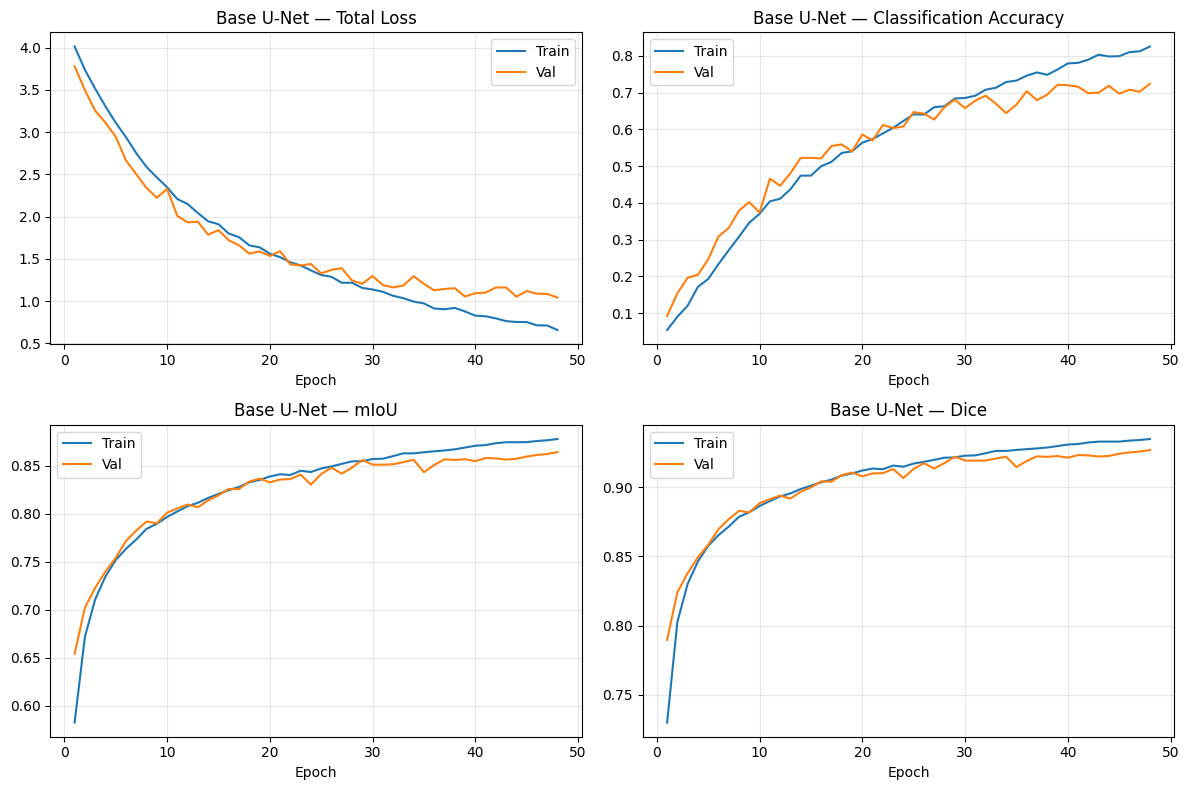

  Base U-Net — TRAIN
  Segmentation   mIoU       : 0.8951
                 Dice       : 0.9445
                 Pixel Acc  : 0.9511
  Classification Accuracy   : 0.9371
                 Precision  : 0.9386
                 Recall     : 0.9371
                 F1 (wt)    : 0.9365

  Base U-Net — VAL
  Segmentation   mIoU       : 0.8641
                 Dice       : 0.9267
                 Pixel Acc  : 0.9400
  Classification Accuracy   : 0.7240
                 Precision  : 0.7471
                 Recall     : 0.7240
                 F1 (wt)    : 0.7243

  Base U-Net — TEST
  Segmentation   mIoU       : 0.8709
                 Dice       : 0.9307
                 Pixel Acc  : 0.9415
  Classification Accuracy   : 0.7551
                 Precision  : 0.7728
                 Recall     : 0.7551
                 F1 (wt)    : 0.7534



In [28]:
# Load best weights before evaluation
best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, BASE_CKPT), map_location=device)
base_model.load_state_dict(best_ckpt["state_dict"])
base_history = best_ckpt.get("history", base_history)

plot_history(base_history, title="Base U-Net")

base_train_metrics = evaluate_split(base_model, train_loader, "Base U-Net — TRAIN")
base_val_metrics   = evaluate_split(base_model, val_loader,   "Base U-Net — VAL")
base_test_metrics  = evaluate_split(base_model, test_loader,  "Base U-Net — TEST")


## 14 — Train Attention U-Net

*Re-running resumes automatically.*

In [29]:
ATT_CKPT = "attention_unet_checkpoint.pth.tar"

att_model = AttentionUNetClassifier(num_breeds=num_classes).to(device)
att_optim = optim.Adam(att_model.parameters(), lr=1e-4, weight_decay=1e-5)
att_sched = optim.lr_scheduler.ReduceLROnPlateau(att_optim, mode="min", patience=5, factor=0.5)

start_epoch, best_loss, att_history = load_checkpoint(ATT_CKPT, att_model, att_optim)

att_history = train_dual_task(
    model           = att_model,
    train_loader    = train_loader,
    val_loader      = val_loader,
    optimizer       = att_optim,
    epochs          = EPOCHS,
    checkpoint_name = ATT_CKPT,
    start_epoch     = start_epoch,
    best_loss       = best_loss,
    history         = att_history,
    scheduler       = att_sched,
)


  [i] No checkpoint at E:\cse428_f\checkpoints\attention_unet_checkpoint.pth.tar. Starting from scratch.


Ep   1/50 | loss 3.9925/3.7435 | acc 0.050/0.096 | IoU 0.601/0.647 | Dice 0.747/0.784
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\attention_unet_checkpoint.pth.tar


Ep   2/50 | loss 3.7181/3.5624 | acc 0.095/0.115 | IoU 0.680/0.700 | Dice 0.809/0.822
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\attention_unet_checkpoint.pth.tar


Ep   3/50 | loss 3.4978/3.4349 | acc 0.127/0.180 | IoU 0.711/0.727 | Dice 0.830/0.840
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\attention_unet_checkpoint.pth.tar


Ep   4/50 | loss 3.2992/3.0645 | acc 0.163/0.233 | IoU 0.736/0.737 | Dice 0.847/0.847
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\attention_unet_checkpoint.pth.tar


...

Ep  46/50 | loss 0.7238/1.1661 | acc 0.806/0.717 | IoU 0.878/0.861 | Dice 0.935/0.925
  EarlyStopping: 3/10


Ep  47/50 | loss 0.7035/1.1018 | acc 0.810/0.712 | IoU 0.880/0.863 | Dice 0.936/0.926
  EarlyStopping: 4/10


Ep  48/50 | loss 0.7001/1.0915 | acc 0.816/0.728 | IoU 0.879/0.864 | Dice 0.935/0.927
  EarlyStopping: 5/10


Ep  49/50 | loss 0.6745/1.1072 | acc 0.825/0.729 | IoU 0.881/0.864 | Dice 0.937/0.927
  EarlyStopping: 6/10


Ep  50/50 | loss 0.5592/0.9814 | acc 0.857/0.760 | IoU 0.889/0.871 | Dice 0.941/0.930
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\attention_unet_checkpoint.pth.tar


## 15 — Evaluate Attention U-Net on all splits

C:\Users\User\AppData\Local\Temp\ipykernel_6628\3339447171.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, ATT_CKPT),

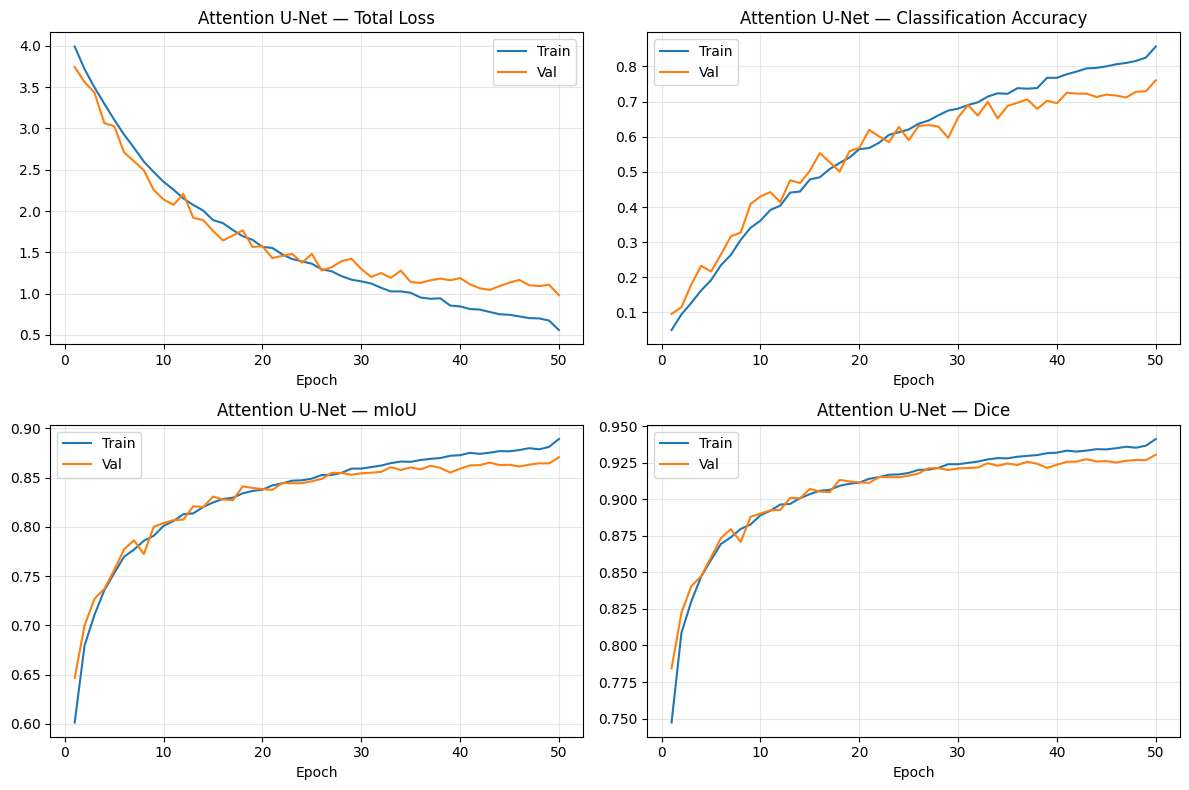

  Attention U-Net — TRAIN
  Segmentation   mIoU       : 0.9081
                 Dice       : 0.9517
                 Pixel Acc  : 0.9575
  Classification Accuracy   : 0.9545
                 Precision  : 0.9552
                 Recall     : 0.9545
                 F1 (wt)    : 0.9543

  Attention U-Net — VAL
  Segmentation   mIoU       : 0.8706
                 Dice       : 0.9304
                 Pixel Acc  : 0.9433
  Classification Accuracy   : 0.7605
                 Precision  : 0.7719
                 Recall     : 0.7605
                 F1 (wt)    : 0.7593

  Attention U-Net — TEST
  Segmentation   mIoU       : 0.8817
                 Dice       : 0.9368
                 Pixel Acc  : 0.9467
  Classification Accuracy   : 0.7862
                 Precision  : 0.7956
                 Recall     : 0.7862
                 F1 (wt)    : 0.7855



In [31]:
best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, ATT_CKPT), map_location=device)
att_model.load_state_dict(best_ckpt["state_dict"])
att_history = best_ckpt.get("history", att_history)

plot_history(att_history, title="Attention U-Net")

att_train_metrics = evaluate_split(att_model, train_loader, "Attention U-Net — TRAIN")
att_val_metrics   = evaluate_split(att_model, val_loader,   "Attention U-Net — VAL")
att_test_metrics  = evaluate_split(att_model, test_loader,  "Attention U-Net — TEST")


## 16 — Side-by-side comparison

In [32]:
import pandas as pd

rows = []
for name, m in [
    ("Base U-Net (Train)",      base_train_metrics),
    ("Base U-Net (Val)",        base_val_metrics),
    ("Base U-Net (Test)",       base_test_metrics),
    ("Attention U-Net (Train)", att_train_metrics),
    ("Attention U-Net (Val)",   att_val_metrics),
    ("Attention U-Net (Test)",  att_test_metrics),
]:
    rows.append({
        "Model / Split": name,
        "mIoU":      f"{m['miou']:.4f}",
        "Dice":      f"{m['dice']:.4f}",
        "PixAcc":    f"{m['pix']:.4f}",
        "Acc":       f"{m['acc']:.4f}",
        "Precision": f"{m['prec']:.4f}",
        "Recall":    f"{m['rec']:.4f}",
        "F1":        f"{m['f1']:.4f}",
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


          Model / Split   mIoU   Dice PixAcc    Acc Precision Recall     F1
     Base U-Net (Train) 0.8951 0.9445 0.9511 0.9371    0.9386 0.9371 0.9365
       Base U-Net (Val) 0.8641 0.9267 0.9400 0.7240    0.7471 0.7240 0.7243
      Base U-Net (Test) 0.8709 0.9307 0.9415 0.7551    0.7728 0.7551 0.7534
Attention U-Net (Train) 0.9081 0.9517 0.9575 0.9545    0.9552 0.9545 0.9543
  Attention U-Net (Val) 0.8706 0.9304 0.9433 0.7605    0.7719 0.7605 0.7593
 Attention U-Net (Test) 0.8817 0.9368 0.9467 0.7862    0.7956 0.7862 0.7855


---

# 🎁 Bonus Task — Data Augmentation Ablation

**Goal:** Quantify how much data augmentation helps.

**Method:** Train an identical Base U-Net **without augmentation** and compare it against the already-trained augmented Base U-Net on the same test split.

**What we vary:** *only* the `train=True` flag on the training `PetDataset`. This toggles:
- Random horizontal flip (p = 0.5)
- Random rotation in ±15°
- Color jitter (brightness, contrast, saturation = 0.2)

**What we keep identical:** architecture, optimizer (Adam, lr=1e-4, weight_decay=1e-5), scheduler, early stopping (patience=10), batch size, image size, seed, train/val/test splits, and number of epochs (50).



In [38]:
# Same train images/masks/labels — only the augmentation flag changes.
train_dataset_noaug = PetDataset(train_imgs, train_masks, breed_to_idx, train=False)

train_loader_noaug = DataLoader(
    train_dataset_noaug,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = (device.type == "cuda"),
)

# Sanity check: confirm augmentation really is off vs on.
img_a, _, _ = train_dataset_noaug[0]
img_b, _, _ = train_dataset_noaug[0]
print(f"NoAug determinism — same sample twice identical? {torch.equal(img_a, img_b)}")

img_c, _, _ = train_dataset[0]
img_d, _, _ = train_dataset[0]
print(f"Aug   determinism — same sample twice identical? {torch.equal(img_c, img_d)}")
print("(Aug should be False, NoAug should be True.)")

NoAug determinism — same sample twice identical? True
Aug   determinism — same sample twice identical? False
(Aug should be False, NoAug should be True.)


In [39]:
NOAUG_CKPT = "base_unet_noaug_checkpoint.pth.tar"

# Re-seed before model creation so weight init matches the augmented run as closely as possible.
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

base_model_noaug = UNetClassifier(num_breeds=num_classes).to(device)
base_optim_noaug = optim.Adam(base_model_noaug.parameters(), lr=1e-4, weight_decay=1e-5)
base_sched_noaug = optim.lr_scheduler.ReduceLROnPlateau(
    base_optim_noaug, mode="min", patience=5, factor=0.5
)

start_epoch, best_loss, noaug_history = load_checkpoint(
    NOAUG_CKPT, base_model_noaug, base_optim_noaug
)

noaug_history = train_dual_task(
    model           = base_model_noaug,
    train_loader    = train_loader_noaug,   # ← no-aug loader
    val_loader      = val_loader,           # validation stays the same
    optimizer       = base_optim_noaug,
    epochs          = EPOCHS,               # same 50 epochs as the aug run
    checkpoint_name = NOAUG_CKPT,
    start_epoch     = start_epoch,
    best_loss       = best_loss,
    history         = noaug_history,
    scheduler       = base_sched_noaug,
)

  [i] No checkpoint at E:\cse428_f\checkpoints\base_unet_noaug_checkpoint.pth.tar. Starting from scratch.


Ep   1/50 | loss 3.9529/3.7425 | acc 0.061/0.093 | IoU 0.610/0.663 | Dice 0.755/0.796
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_noaug_checkpoint.pth.tar


Ep   2/50 | loss 3.6309/3.3824 | acc 0.106/0.158 | IoU 0.687/0.703 | Dice 0.814/0.825
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_noaug_checkpoint.pth.tar


Ep   3/50 | loss 3.3507/3.2151 | acc 0.154/0.199 | IoU 0.722/0.736 | Dice 0.838/0.847
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_noaug_checkpoint.pth.tar


Ep   4/50 | loss 3.1236/2.9733 | acc 0.194/0.252 | IoU 0.743/0.754 | Dice 0.852/0.859
  [✓] Checkpoint saved → E:\cse428_f\checkpoints\base_unet_noaug_checkpoint.pth.tar


...

Ep  36/50 | loss 0.4165/1.6767 | acc 0.908/0.621 | IoU 0.888/0.852 | Dice 0.941/0.920
  EarlyStopping: 6/10


Ep  37/50 | loss 0.2960/1.5139 | acc 0.944/0.658 | IoU 0.902/0.856 | Dice 0.949/0.922
  EarlyStopping: 7/10


Ep  38/50 | loss 0.2496/1.5702 | acc 0.956/0.655 | IoU 0.907/0.858 | Dice 0.951/0.923
  EarlyStopping: 8/10


Ep  39/50 | loss 0.2410/1.6123 | acc 0.954/0.644 | IoU 0.908/0.856 | Dice 0.952/0.922
  EarlyStopping: 9/10


Ep  40/50 | loss 0.2272/1.5605 | acc 0.962/0.674 | IoU 0.909/0.857 | Dice 0.952/0.922
  EarlyStopping: 10/10
Early stopping triggered. Best checkpoint already saved.


C:\Users\User\AppData\Local\Temp\ipykernel_6628\135519455.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, NOAUG_CKPT)

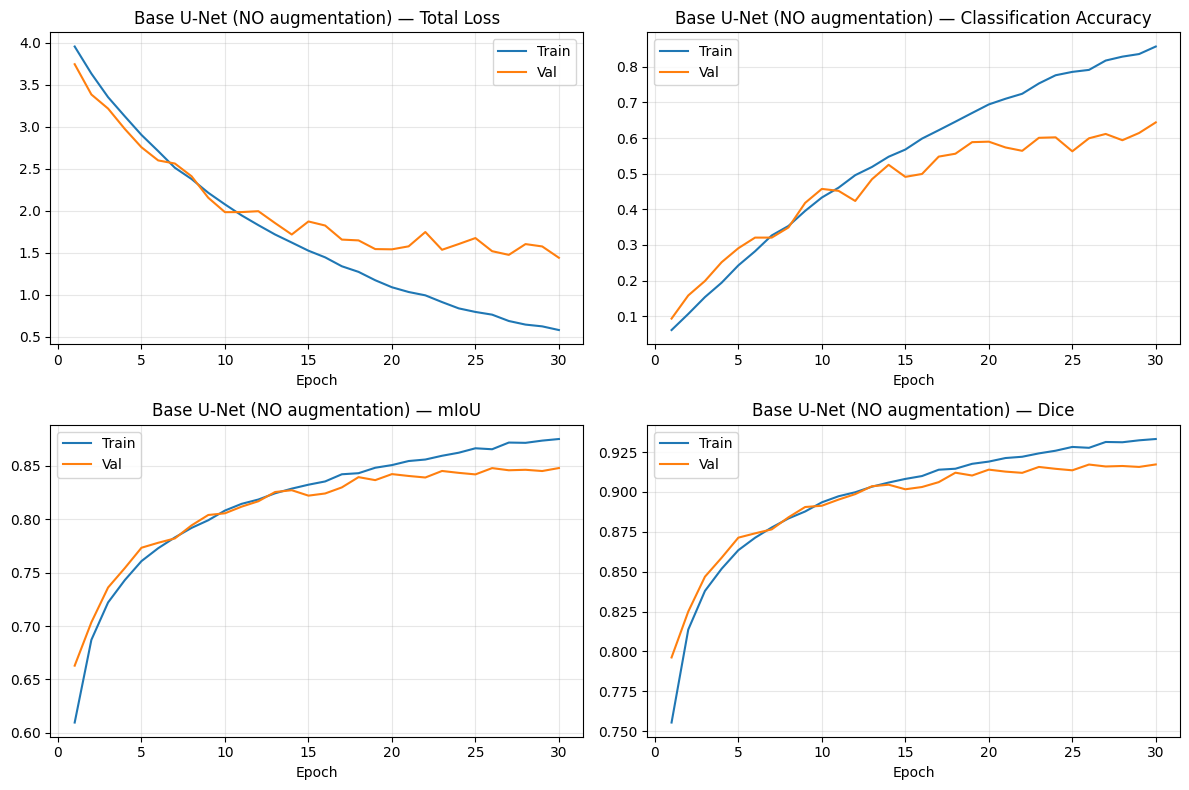

  Base U-Net NO-AUG — TRAIN
  Segmentation   mIoU       : 0.8134
                 Dice       : 0.8966
                 Pixel Acc  : 0.9110
  Classification Accuracy   : 0.7717
                 Precision  : 0.7910
                 Recall     : 0.7717
                 F1 (wt)    : 0.7714

  Base U-Net NO-AUG — VAL
  Segmentation   mIoU       : 0.8480
                 Dice       : 0.9173
                 Pixel Acc  : 0.9321
  Classification Accuracy   : 0.6441
                 Precision  : 0.6649
                 Recall     : 0.6441
                 F1 (wt)    : 0.6424

  Base U-Net NO-AUG — TEST
  Segmentation   mIoU       : 0.8550
                 Dice       : 0.9215
                 Pixel Acc  : 0.9337
  Classification Accuracy   : 0.6671
                 Precision  : 0.6939
                 Recall     : 0.6671
                 F1 (wt)    : 0.6710



In [40]:
# Load best no-aug checkpoint
best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, NOAUG_CKPT), map_location=device)
base_model_noaug.load_state_dict(best_ckpt["state_dict"])
noaug_history = best_ckpt.get("history", noaug_history)

plot_history(noaug_history, title="Base U-Net (NO augmentation)")

noaug_train_metrics = evaluate_split(base_model_noaug, train_loader, "Base U-Net NO-AUG — TRAIN")
noaug_val_metrics   = evaluate_split(base_model_noaug, val_loader,   "Base U-Net NO-AUG — VAL")
noaug_test_metrics  = evaluate_split(base_model_noaug, test_loader,  "Base U-Net NO-AUG — TEST")

In [41]:
import pandas as pd

def diff_pct(aug_val, noaug_val):
    """Relative improvement (%) of aug over no-aug."""
    if noaug_val == 0:
        return float("inf")
    return (aug_val - noaug_val) / abs(noaug_val) * 100.0

# Compare on TEST set (the fairest comparison)
metrics_keys = [("mIoU", "miou"), ("Dice", "dice"), ("PixAcc", "pix"),
                ("Acc", "acc"), ("Precision", "prec"), ("Recall", "rec"), ("F1", "f1")]

rows = []
for label, key in metrics_keys:
    n = noaug_test_metrics[key]
    a = base_test_metrics[key]
    rows.append({
        "Metric":       label,
        "No Aug":       f"{n:.4f}",
        "With Aug":     f"{a:.4f}",
        "Δ (absolute)": f"{(a - n):+.4f}",
        "Δ (relative)": f"{diff_pct(a, n):+.2f}%",
    })

ablation_df = pd.DataFrame(rows)
print("=" * 70)
print("  AUGMENTATION ABLATION — Base U-Net on TEST set")
print("=" * 70)
print(ablation_df.to_string(index=False))
print("=" * 70)

  AUGMENTATION ABLATION — Base U-Net on TEST set
   Metric No Aug With Aug Δ (absolute) Δ (relative)
     mIoU 0.8550   0.8709      +0.0159       +1.85%
     Dice 0.9215   0.9307      +0.0091       +0.99%
   PixAcc 0.9337   0.9415      +0.0078       +0.84%
      Acc 0.6671   0.7551      +0.0880      +13.18%
Precision 0.6939   0.7728      +0.0789      +11.38%
   Recall 0.6671   0.7551      +0.0880      +13.18%
       F1 0.6710   0.7534      +0.0823      +12.27%


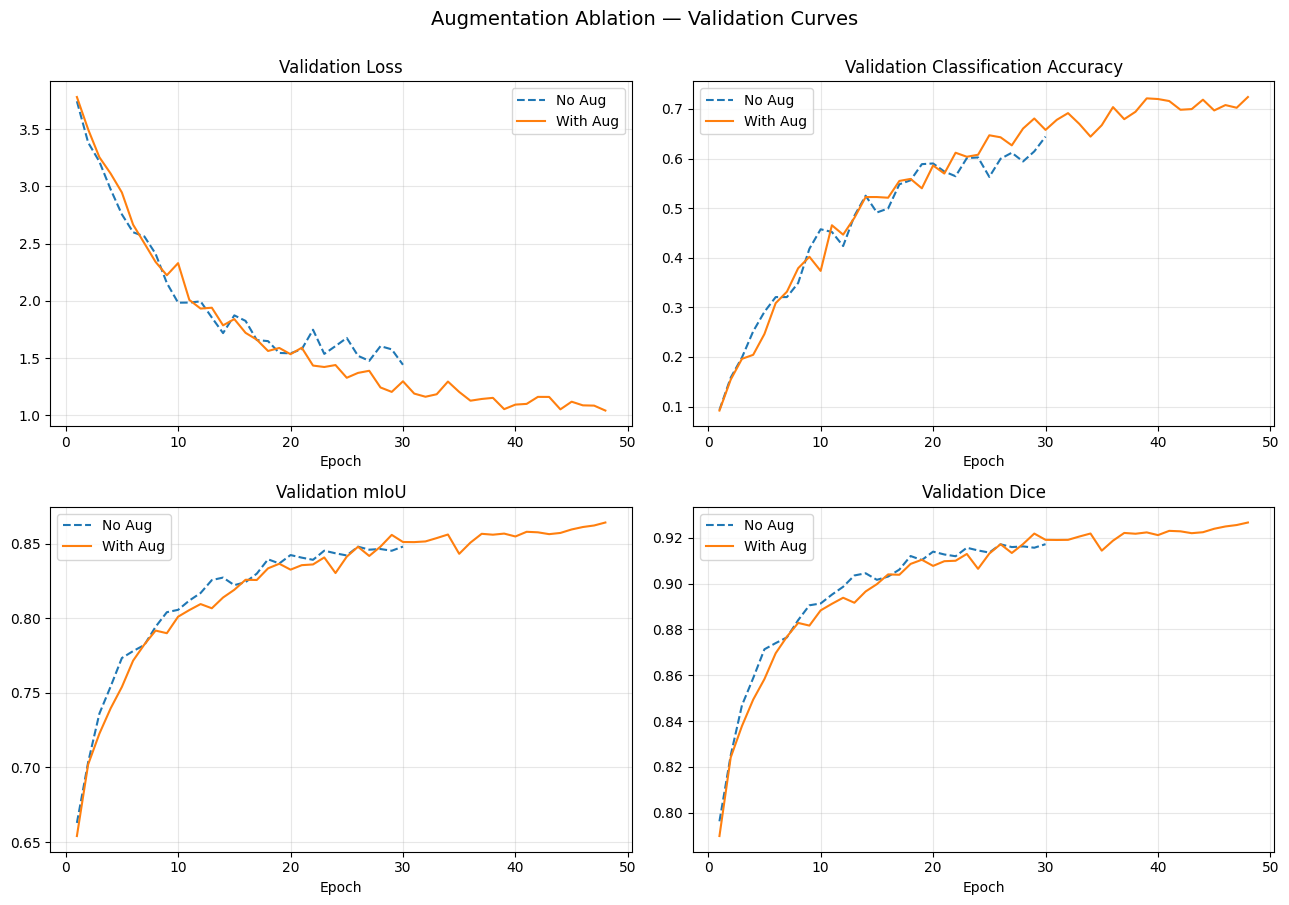

In [42]:
# Overlay validation curves so the regularizing effect of augmentation is visible.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ep_aug   = range(1, len(base_history["val_loss"])  + 1)
ep_noaug = range(1, len(noaug_history["val_loss"]) + 1)

axes[0, 0].plot(ep_noaug, noaug_history["val_loss"], label="No Aug", linestyle="--")
axes[0, 0].plot(ep_aug,   base_history["val_loss"],  label="With Aug")
axes[0, 0].set_title("Validation Loss"); axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(ep_noaug, noaug_history["val_acc"], label="No Aug", linestyle="--")
axes[0, 1].plot(ep_aug,   base_history["val_acc"],  label="With Aug")
axes[0, 1].set_title("Validation Classification Accuracy"); axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(ep_noaug, noaug_history["val_iou"], label="No Aug", linestyle="--")
axes[1, 0].plot(ep_aug,   base_history["val_iou"],  label="With Aug")
axes[1, 0].set_title("Validation mIoU"); axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ep_noaug, noaug_history["val_dice"], label="No Aug", linestyle="--")
axes[1, 1].plot(ep_aug,   base_history["val_dice"],  label="With Aug")
axes[1, 1].set_title("Validation Dice"); axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.suptitle("Augmentation Ablation — Validation Curves", fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

In [43]:
# Train-vs-Val gap is the cleanest signal that augmentation regularizes.
# A larger gap means more overfitting.

print("=" * 70)
print("  OVERFITTING CHECK — Train vs Val gap (smaller = better generalization)")
print("=" * 70)
print(f"\n{'Metric':<15}{'No Aug Gap':<18}{'With Aug Gap':<18}{'Verdict'}")
print("-" * 70)

for label, key in [("Acc", "acc"), ("mIoU", "miou"), ("Dice", "dice")]:
    gap_noaug = noaug_train_metrics[key] - noaug_val_metrics[key]
    gap_aug   = base_train_metrics[key]  - base_val_metrics[key]
    verdict   = "Aug reduces gap ✓" if gap_aug < gap_noaug else "No reduction ✗"
    print(f"{label:<15}{gap_noaug:+.4f}{'':<10}{gap_aug:+.4f}{'':<10}{verdict}")
print("=" * 70)

  OVERFITTING CHECK — Train vs Val gap (smaller = better generalization)

Metric         No Aug Gap        With Aug Gap      Verdict
----------------------------------------------------------------------
Acc            +0.1275          +0.2131          No reduction ✗
mIoU           -0.0347          +0.0309          No reduction ✗
Dice           -0.0206          +0.0178          No reduction ✗


In [44]:
# Fair train-metrics: evaluate both models on the SAME non-augmented train images.
eval_train_loader = DataLoader(
    PetDataset(train_imgs, train_masks, breed_to_idx, train=False),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
)

print("Re-evaluating with clean train images for a fair overfitting comparison ...\n")
fair_aug_train   = evaluate_split(base_model,        eval_train_loader, "Aug   model — clean train")
fair_noaug_train = evaluate_split(base_model_noaug,  eval_train_loader, "NoAug model — clean train")

print("\n" + "=" * 70)
print("  FAIR OVERFITTING CHECK (clean train images for both)")
print("=" * 70)
print(f"\n{'Metric':<12}{'NoAug Gap':<15}{'Aug Gap':<15}{'Verdict'}")
print("-" * 70)
for label, key in [("Acc","acc"), ("mIoU","miou"), ("Dice","dice")]:
    g_noaug = fair_noaug_train[key] - noaug_test_metrics[key]
    g_aug   = fair_aug_train[key]   - base_test_metrics[key]
    verdict = "Aug regularizes ✓" if g_aug < g_noaug else "No reduction ✗"
    print(f"{label:<12}{g_noaug:+.4f}{'':<7}{g_aug:+.4f}{'':<7}{verdict}")
print("=" * 70)

Re-evaluating with clean train images for a fair overfitting comparison ...

  Aug   model — clean train
  Segmentation   mIoU       : 0.8957
                 Dice       : 0.9448
                 Pixel Acc  : 0.9541
  Classification Accuracy   : 0.9562
                 Precision  : 0.9568
                 Recall     : 0.9562
                 F1 (wt)    : 0.9558

  NoAug model — clean train
  Segmentation   mIoU       : 0.8988
                 Dice       : 0.9466
                 Pixel Acc  : 0.9556
  Classification Accuracy   : 0.9704
                 Precision  : 0.9726
                 Recall     : 0.9704
                 F1 (wt)    : 0.9703


  FAIR OVERFITTING CHECK (clean train images for both)

Metric      NoAug Gap      Aug Gap        Verdict
----------------------------------------------------------------------
Acc         +0.3033       +0.2011       Aug regularizes ✓
mIoU        +0.0438       +0.0248       Aug regularizes ✓
Dice        +0.0251       +0.0141       Aug regulariz

## 17 — Per-image prediction visualisation

The required output format:

```
Original class  : <breed> (cat/dog)
Predicted class : <breed> (cat/dog)
IoU             : XX.X %

[ Original image ] [ Image + True mask overlay ] [ Image + Predicted mask overlay ]
```

During the demo, change `INDEX` and re-run the last cell.


Test-set size: 739

--- Base U-Net ---


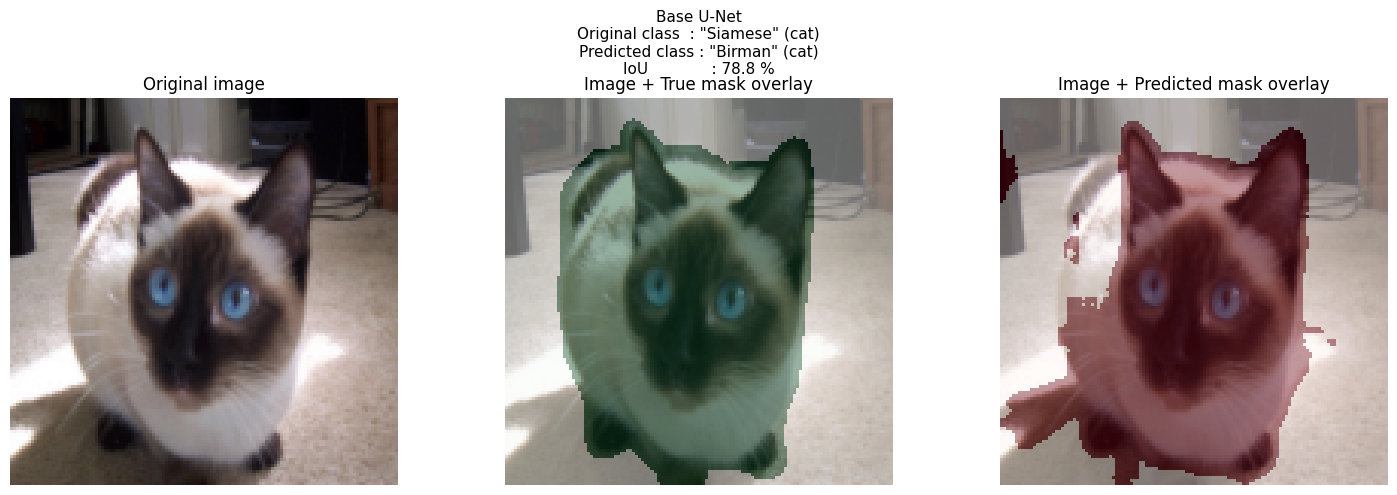

--- Attention U-Net ---


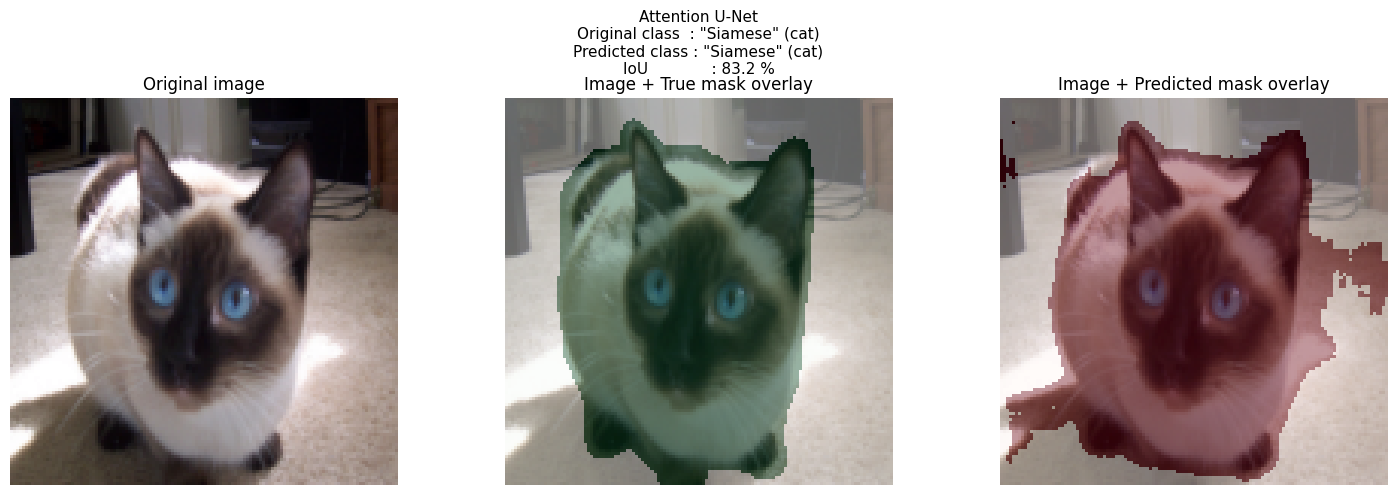

In [34]:
def denormalize_image(image_tensor):
    """Reverse ImageNet normalization for display."""
    img = image_tensor.clone().cpu()
    for c in range(3):
        img[c] = img[c] * STD[c] + MEAN[c]
    return img.permute(1, 2, 0).clamp(0, 1).numpy()


def visualise_prediction(model, dataset, idx: int, model_name: str = "Model"):
    """
    Display a single sample in the required 3-panel format and print
    original class, predicted class, and per-image IoU.
    """
    model.eval()
    image, mask, label = dataset[idx]

    with torch.no_grad():
        m_p, c_p = model(image.unsqueeze(0).to(device))

    pred_mask  = (torch.sigmoid(m_p) > 0.5).float().squeeze().cpu().numpy()
    true_mask  = mask.numpy()
    pred_label = c_p.argmax(1).item()

    intersection = (pred_mask * true_mask).sum()
    union        = ((pred_mask + true_mask) > 0).sum()
    iou          = intersection / (union + 1e-7)

    img_disp = denormalize_image(image)

    # Use the underlying file path to recover species reliably
    img_path     = dataset.image_paths[idx]
    orig_breed_k = idx_to_breed[label.item()]
    pred_breed_k = idx_to_breed[pred_label]

    def fmt(breed_key):
        # In the Oxford-IIIT convention the raw breed key keeps its original case
        species = "cat" if breed_key[0].isupper() else "dog"
        pretty  = " ".join(p.capitalize() for p in breed_key.split("_"))
        return f'"{pretty}" ({species})'

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f'{model_name}\n'
        f'Original class  : {fmt(orig_breed_k)}\n'
        f'Predicted class : {fmt(pred_breed_k)}\n'
        f'IoU             : {iou*100:.1f} %',
        fontsize=11,
    )

    axes[0].imshow(img_disp)
    axes[0].set_title("Original image"); axes[0].axis("off")

    axes[1].imshow(img_disp)
    axes[1].imshow(true_mask, alpha=0.4, cmap="Greens")
    axes[1].set_title("Image + True mask overlay"); axes[1].axis("off")

    axes[2].imshow(img_disp)
    axes[2].imshow(pred_mask, alpha=0.4, cmap="Reds")
    axes[2].set_title("Image + Predicted mask overlay"); axes[2].axis("off")

    plt.tight_layout(); plt.show()


# ── Demo: change INDEX or pass any test-set index ──────────────────────────
INDEX = 0   # any int in [0, len(test_dataset))
print(f"Test-set size: {len(test_dataset)}\n")

print("--- Base U-Net ---")
visualise_prediction(base_model, test_dataset, INDEX, model_name="Base U-Net")

print("--- Attention U-Net ---")
visualise_prediction(att_model, test_dataset, INDEX, model_name="Attention U-Net")


## 18 — Random-index demo grid (for presentation)

Per the spec: *"For your presentation part, you can adhere to random indices to pass through your model."*
This cell picks 3 random test indices and shows both models' predictions side-by-side.


=== Base U-Net — random demo ===


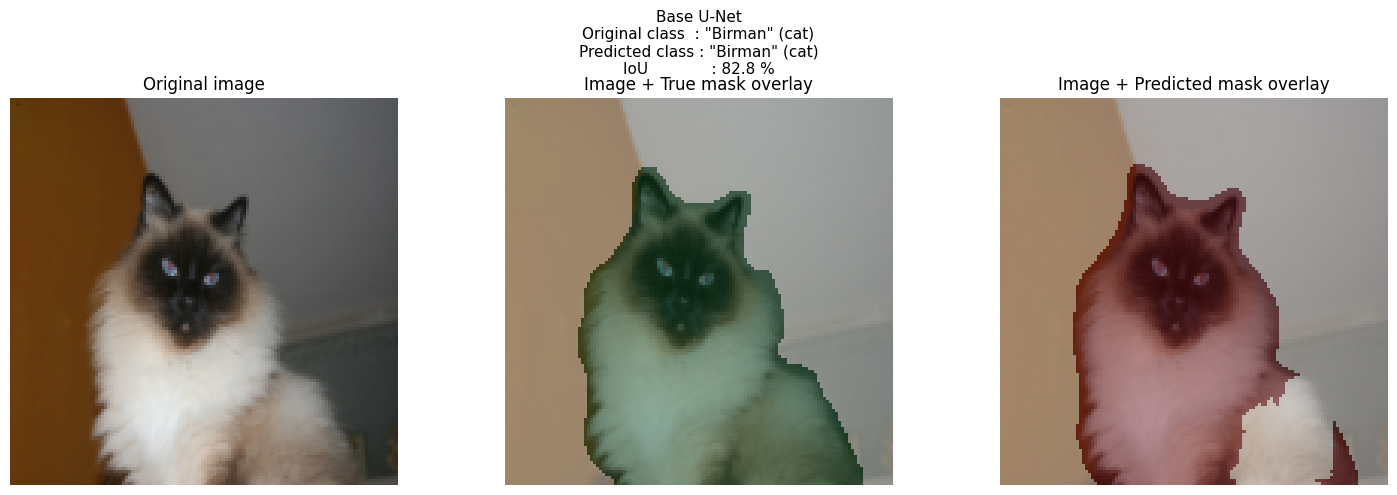

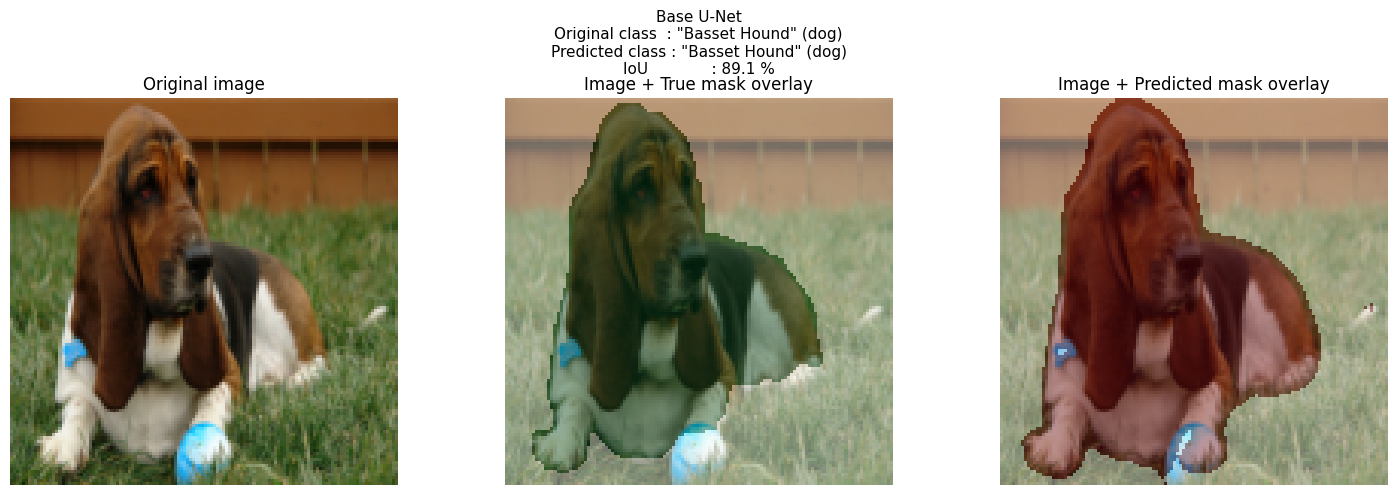

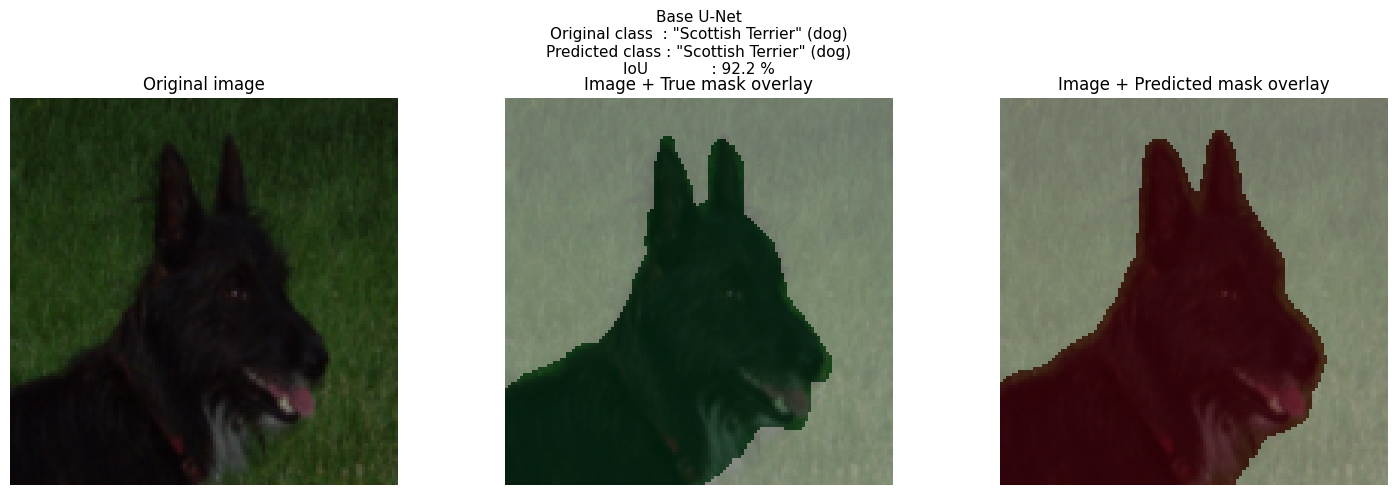

=== Attention U-Net — random demo ===


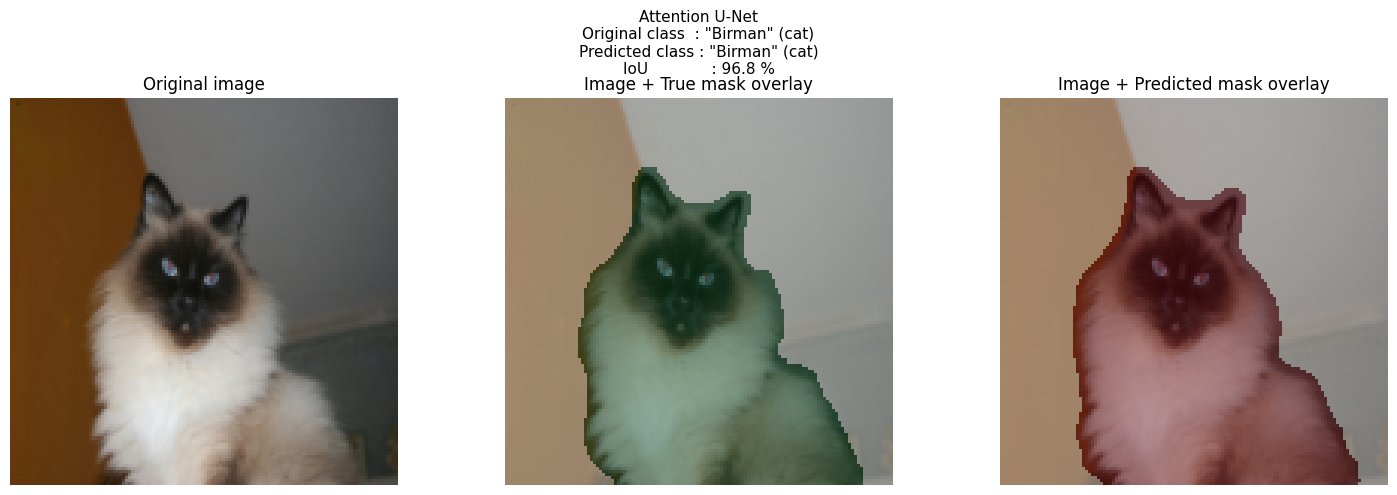

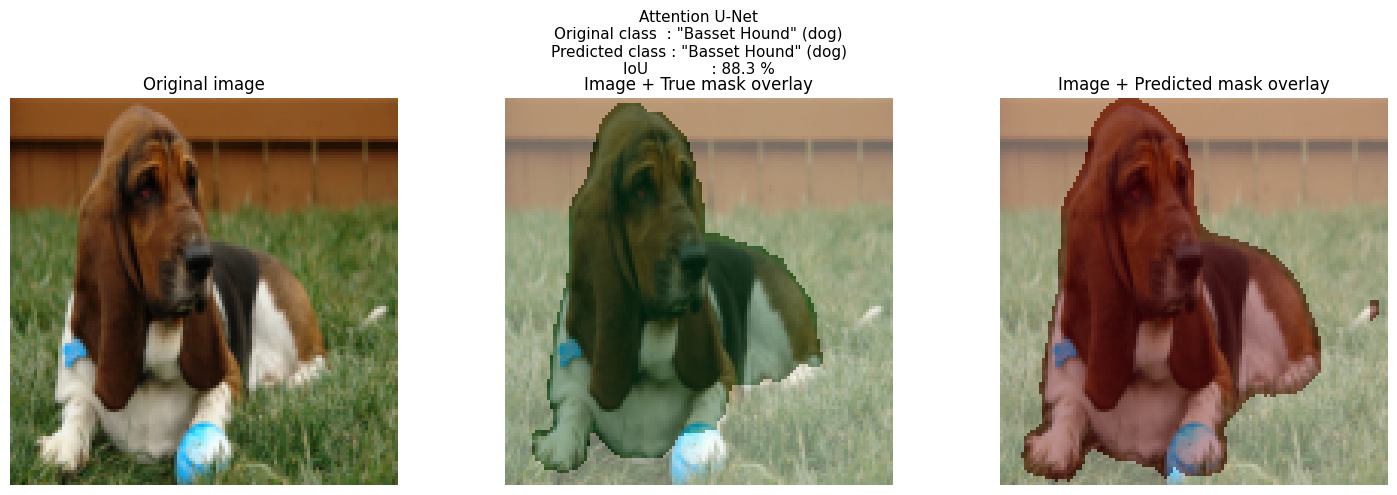

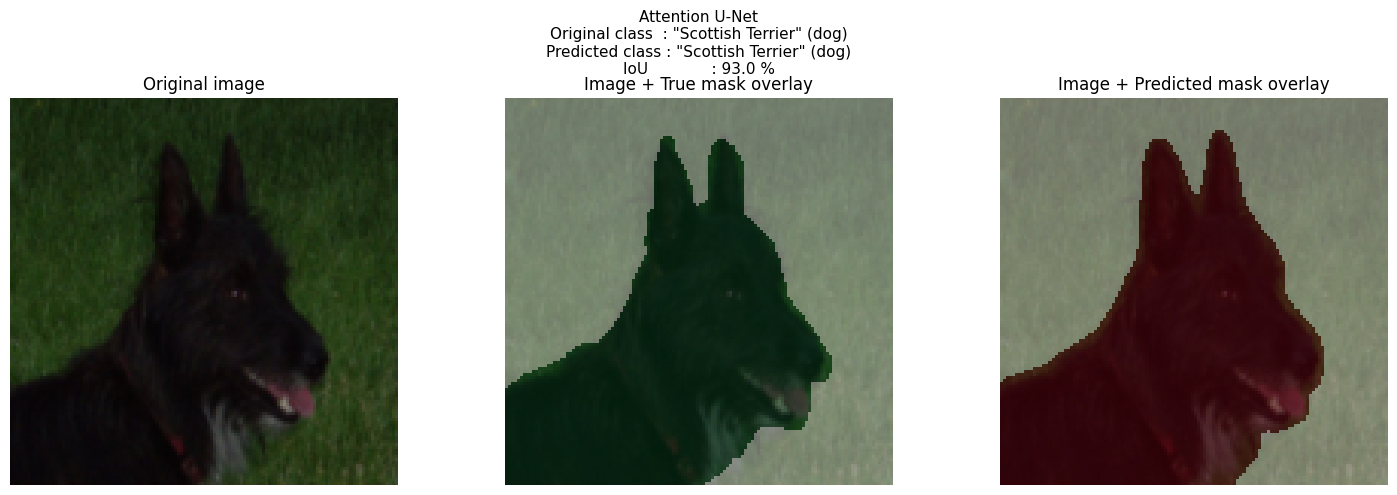

In [37]:
def demo_random_indices(model, dataset, n: int = 3, model_name: str = "Model", seed: int = 7):
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n)
    for i in indices:
        visualise_prediction(model, dataset, i, model_name=model_name)


print("=== Base U-Net — random demo ===")
demo_random_indices(base_model, test_dataset, n=3, model_name="Base U-Net", seed=8)

print("=== Attention U-Net — random demo ===")
demo_random_indices(att_model, test_dataset, n=3, model_name="Attention U-Net", seed=8)
